In [1]:
import torch
import pandas as pd
from scipy.spatial import distance
import numpy as np
from raftup import (
    _downsample,
    _fsgw_utils,
    _metrics_two_gpr,
    _load_data,
    _plot,
    _recoverfull_new_new_knn
)

/opt/anaconda3/envs/raftup/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/opt/anaconda3/envs/raftup/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


In [2]:

random_state = 23
np.random.seed(random_state)

section_ids_list = [['-0.04', '-0.09']]
pair = ['-0.04', '-0.09']
ds_pts = 200

for section_ids in section_ids_list:
    dataset = section_ids[0] + '_' + section_ids[1]

    sliceA = _load_data.load_mHypothalamus(root_dir='./mHypothalamus',section_id=section_ids[0])
    sliceB = _load_data.load_mHypothalamus(root_dir='./mHypothalamus',section_id=section_ids[1])


D_A = distance.cdist(sliceA.obsm['spatial'], sliceA.obsm['spatial'])
D_B = distance.cdist(sliceB.obsm['spatial'], sliceB.obsm['spatial'])
TestA = D_A[D_A>0]
TestB = D_B[D_B>0]
print(np.min(TestA), np.min(TestB), np.max(TestA), np.max(TestB))

/opt/anaconda3/envs/raftup/lib/python3.10/site-packages/anndata/_core/anndata.py:117: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


3.235455771330554 2.1911319540983416 2494.720899495855 2498.44176091063


/opt/anaconda3/envs/raftup/lib/python3.10/site-packages/anndata/_core/anndata.py:117: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [3]:
downsampled_sliceA,indices_dsa = _downsample.maxmin_downsample_slice_merfish(sliceA, ds_pts)
downsampled_sliceB,indices_dsb = _downsample.maxmin_downsample_slice_merfish(sliceB, ds_pts)

D_A_test = distance.cdist(downsampled_sliceA.obsm['spatial'], downsampled_sliceA.obsm['spatial'])
D_B_test = distance.cdist(downsampled_sliceB.obsm['spatial'], downsampled_sliceB.obsm['spatial'])
testA = D_A_test[D_A_test>0]
testB = D_B_test[D_B_test>0]
slice_scale = np.min([np.max(testA), np.max(testB)])
print(np.min(testA), np.min(testB), np.max(testA), np.max(testB))

98.50759140234227 97.67900930377812 2485.288735388629 2498.44176091063


In [4]:
PT_PATH = f"./results/gene_cost_matrix/{pair[0]}_{pair[1]}_somde_cost_matrix.pt"

C = torch.load(PT_PATH, map_location="cpu")  # torch.Tensor
M = C.numpy() # full cost matrix


transported mass: 0.3526573533306361
full_LAA: 0.7916666666666666
Number of columns with >=2 nonzeros: 1
(200, 200)


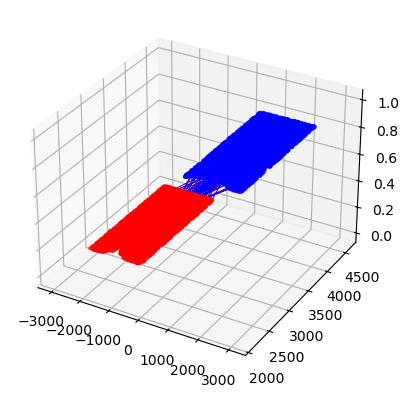

In [5]:
from pathlib import Path
import numpy as np

SAVE_DIR = Path("./results/align_data")

load_path = SAVE_DIR / f"ds_matching_{pair}_{100}_{0.2}.npy"

P_1 = np.load(load_path)

P_hard = np.zeros_like(P_1)
row_max_idx = P_1.argmax(axis=1) 
P_hard[np.arange(P_1.shape[0]), row_max_idx] = P_1[np.arange(P_1.shape[0]), row_max_idx]

test_label_sub = np.concatenate((np.array(downsampled_sliceA.obs['original_clusters']),np.array(downsampled_sliceB.obs['original_clusters'])),axis=0)
XA_sub = downsampled_sliceA.obsm['spatial']
XB_sub = downsampled_sliceB.obsm['spatial']

full_dela_raftup_LAA = _metrics_two_gpr.cal_layer_based_alignment_result_merfish_skill_all_zero(P_hard, test_label_sub)

print("transported mass:", P_hard.sum())
print("full_LAA:", full_dela_raftup_LAA)

col_nnz = np.count_nonzero(P_hard, axis=0)  
conflict_cols = np.where(col_nnz >= 2)[0]
num_conflict_cols = len(conflict_cols)

print("Number of columns with >=2 nonzeros:", num_conflict_cols)

print(P_hard.shape)

_plot.plot_3d(sliceA.obsm['spatial'], sliceB.obsm['spatial'], P_hard, indices_dsa, indices_dsb, linewidth=0.5)

In [6]:
thresh_CCC_list = {0.2}

thresh_CGW_list = {60}


test_label_full = np.concatenate((np.array(sliceA.obs['original_clusters']),np.array(sliceB.obs['original_clusters'])),axis=0)
XA_full = sliceA.obsm['spatial']
XB_full = sliceB.obsm['spatial']

for thresh_CCC in thresh_CCC_list:
    for thresh_CGW in thresh_CGW_list:
        print(f"Running alignment for section pair")
        P_full_knn = _recoverfull_new_new_knn.recover_full_mapping_knn(
            M = M,
            X1 = sliceA.obsm['spatial'],
            X2 = sliceB.obsm['spatial'],
            P  = P_hard,
            idx1 = indices_dsa,
            idx2 = indices_dsb,
            k1 = 10,         
            k2 = 10,         
            thresh_CGW=thresh_CGW, 
            thresh_CCC=thresh_CCC, 
            eps=0.01
        )
        P_full_dense_knn = P_full_knn.toarray()

        full_dela_raftup_LAA = _metrics_two_gpr.cal_layer_based_alignment_result_merfish_skill_all_zero(P_full_dense_knn, test_label_full)
        full_dela_raftup_GPR_15= _metrics_two_gpr.GPR_original(P_full_dense_knn , XA_full, XB_full, dis_cut=15, P_cut=1e-19)
        full_dela_raftup_GPR_20= _metrics_two_gpr.GPR_original(P_full_dense_knn , XA_full, XB_full, dis_cut=20, P_cut=1e-19)
        full_dela_raftup_GPR_30= _metrics_two_gpr.GPR_original(P_full_dense_knn , XA_full, XB_full, dis_cut=30, P_cut=1e-19)

        print("transported mass:", P_full_dense_knn.sum())
        print("full_LAA:", full_dela_raftup_LAA)
        print("thresholds:", thresh_CGW, thresh_CCC)
        print("full_GPR_15:", full_dela_raftup_GPR_15)
        print("full_GPR_20:", full_dela_raftup_GPR_20)
        print("full_GPR_30:", full_dela_raftup_GPR_30)
        np.save(f'./results/align_data/full_matching_{pair}_{thresh_CGW}_{thresh_CCC}.npy',P_full_dense_knn)

Running alignment for section pair


recover_full_mapping_knn:  75%|███████▌  | 6/8 [03:46<01:14, 37.30s/it]

Number of blocked positions in recover_full sOT (kNN): 30471313
Number of possible aligned positions (kNN): 25503


Number of iterations in unot: 20001, final error: 1.70e-05
transported mass: 0.50058239277978
full_LAA: 0.7772103415256942
thresholds: 60 0.2
full_GPR_15: 0.6689801548283885
full_GPR_20: 0.6285997976343854
full_GPR_30: 0.6325147787429444
